<a href="https://colab.research.google.com/github/JayaVishal23/Bird-Call-Classifier/blob/main/Bird.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip '/content/bird_spectrograms.zip' -d spectograms

Archive:  /content/bird_spectrograms.zip
   creating: spectograms/Acridotheres_tristis/
   creating: spectograms/Alcedo_atthis/
   creating: spectograms/Amaurornis_phoenicurus/
   creating: spectograms/Ardeola_grayii/
   creating: spectograms/Argya_striata/
   creating: spectograms/Centropus_sinensis/
   creating: spectograms/Cinnyris_asiaticus/
   creating: spectograms/Columba_livia/
   creating: spectograms/Coracias_benghalensis/
   creating: spectograms/Dendrocitta_vagabunda/
   creating: spectograms/Dicrurus_macrocercus/
   creating: spectograms/Eudynamys_scolopaceus/
   creating: spectograms/Halcyon_smyrnensis/
   creating: spectograms/Merops_orientalis/
   creating: spectograms/Milvus_migrans/
   creating: spectograms/Orthotomus_sutorius/
   creating: spectograms/Ortygornis_pondicerianus/
   creating: spectograms/Passer_domesticus/
   creating: spectograms/Pavo_cristatus/
   creating: spectograms/Prinia_socialis/
   creating: spectograms/Psilopogon_haemacephalus/
   creating: spe

In [6]:
import os
import json
import random
import shutil

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [10]:
RAW_DIR     = "/content/spectograms"
SPLIT_DIR   = "/content/bird_dataset"
MODEL_OUT   = "bird_classifier.keras"
CLASSES_OUT = "class_names.json"

In [11]:
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 25
SPLIT_RATIOS  = (0.70, 0.15, 0.15)
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def split_dataset(raw_dir, split_dir, ratios=(0.7, 0.15, 0.15), seed=42):
    assert abs(sum(ratios) - 1.0) < 1e-6, "ratios must sum to 1"
    rng = random.Random(seed)
    shutil.rmtree(split_dir, ignore_errors=True)   # fresh start on re-runs

    classes = sorted(
        d for d in os.listdir(raw_dir)
        if os.path.isdir(os.path.join(raw_dir, d))
    )
    for split in ("train", "val", "test"):
        for c in classes:
            os.makedirs(os.path.join(split_dir, split, c), exist_ok=True)

    summary = {}
    for c in classes:
        files = [
            f for f in os.listdir(os.path.join(raw_dir, c))
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        rng.shuffle(files)
        n = len(files)
        n_train = int(ratios[0] * n)
        n_val   = int(ratios[1] * n)
        parts = {
            "train": files[:n_train],
            "val":   files[n_train:n_train + n_val],
            "test":  files[n_train + n_val:],
        }
        for split, fs in parts.items():
            for f in fs:
                shutil.copy(os.path.join(raw_dir, c, f),
                            os.path.join(split_dir, split, c, f))
        summary[c] = {k: len(v) for k, v in parts.items()}

    print(f"{'class':32s} train  val  test")
    for c, s in summary.items():
        print(f"{c:32s} {s['train']:5d} {s['val']:4d} {s['test']:4d}")
    tot = {k: sum(s[k] for s in summary.values()) for k in ("train", "val", "test")}
    print(f"\nTOTAL  train={tot['train']}  val={tot['val']}  test={tot['test']}")
    return classes


In [ ]:
CLASS_NAMES = split_dataset(RAW_DIR, SPLIT_DIR, SPLIT_RATIOS, SEED)
NUM_CLASSES = len(CLASS_NAMES)
print("\nNum classes:", NUM_CLASSES)

class                            train  val  test
Acridotheres_tristis                28    6    6
Alcedo_atthis                       20    4    5
Amaurornis_phoenicurus              28    6    6
Ardeola_grayii                       8    1    3
Argya_striata                       28    6    6
Centropus_sinensis                  28    6    6
Cinnyris_asiaticus                  28    6    6
Columba_livia                       28    6    6
Coracias_benghalensis               28    6    6
Dendrocitta_vagabunda               28    6    6
Dicrurus_macrocercus                28    6    6
Eudynamys_scolopaceus               28    6    6
Halcyon_smyrnensis                  28    6    6
Merops_orientalis                    9    1    3
Milvus_migrans                      28    6    6
Orthotomus_sutorius                 28    6    6
Ortygornis_pondicerianus            15    3    4
Passer_domesticus                   28    6    6
Pavo_cristatus                      28    6    6
Prinia_socialis    

In [ ]:
train_dir = os.path.join(SPLIT_DIR, "train")
val_dir   = os.path.join(SPLIT_DIR, "val")
test_dir  = os.path.join(SPLIT_DIR, "test")


In [ ]:
train_raw = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=None,
    shuffle=True, seed=SEED, label_mode="int",
)
class_names = train_raw.class_names           # canonical order from Keras
assert class_names == CLASS_NAMES, "class order mismatch"

val_ds = keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode="int",
).cache().prefetch(AUTOTUNE)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode="int",
).prefetch(AUTOTUNE)


Found 724 files belonging to 28 classes.
Found 153 files belonging to 28 classes.
Found 159 files belonging to 28 classes.


In [ ]:
def spec_augment(image, freq_mask=24, time_mask=24, n_freq=2, n_time=2):
    """SpecAugment: mask bands of frequency (rows) and time (cols).
    Correct for spectrograms - unlike rotation/flip it respects that the
    y-axis is frequency and the x-axis is time, which are not interchangeable."""
    image = tf.cast(image, tf.float32)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    for _ in range(n_freq):                       # frequency masking (rows)
        f  = tf.random.uniform([], 0, freq_mask, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, h - f, dtype=tf.int32)
        idx = tf.range(h)
        keep = tf.logical_or(idx < f0, idx >= f0 + f)
        image *= tf.reshape(tf.cast(keep, tf.float32), [h, 1, 1])

    for _ in range(n_time):                        # time masking (cols)
        t  = tf.random.uniform([], 0, time_mask, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, w - t, dtype=tf.int32)
        idx = tf.range(w)
        keep = tf.logical_or(idx < t0, idx >= t0 + t)
        image *= tf.reshape(tf.cast(keep, tf.float32), [1, w, 1])

    image *= tf.random.uniform([], 0.9, 1.1)       # mild gain (loudness) variation
    return tf.clip_by_value(image, 0.0, 255.0)


In [ ]:
train_ds = (
    train_raw
    .cache()
    .shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    .map(lambda x, y: (spec_augment(x), y), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
train_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in class_names}
total_train  = sum(train_counts.values())
class_weight = {
    i: total_train / (NUM_CLASSES * train_counts[class_names[i]])
    for i in range(NUM_CLASSES)
}
print("Smallest classes (these will be your weakest):",
      sorted(train_counts.items(), key=lambda kv: kv[1])[:5])

Smallest classes (these will be your weakest): [('Ardeola_grayii', 8), ('Merops_orientalis', 9), ('Ortygornis_pondicerianus', 15), ('Alcedo_atthis', 20), ('Acridotheres_tristis', 28)]


In [ ]:
base_model = keras.applications.EfficientNetB0(
    include_top=False, input_shape=(*IMG_SIZE, 3), weights="imagenet",
)
base_model.trainable = False                  # Stage 1

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(
    NUM_CLASSES, activation="softmax",
    kernel_regularizer=keras.regularizers.l2(1e-4),
)(x)
model = keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def make_callbacks(tag):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
        keras.callbacks.ModelCheckpoint(
            f"best_{tag}.keras", monitor="val_accuracy", save_best_only=True),
    ]


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_STAGE1, class_weight=class_weight,
    callbacks=make_callbacks("stage1"),
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 76s 806ms/step - accuracy: 0.0580 - loss: 3.4492 - val_accuracy: 0.0980 - val_loss: 3.1847 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.1091 - loss: 3.1622 - val_accuracy: 0.2353 - val_loss: 2.9632 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.1657 - loss: 2.9591 - val_accuracy: 0.2549 - val_loss: 2.8292 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2155 - loss: 2.8168 - val_accuracy: 0.2941 - val_loss: 2.7061 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2431 - loss: 2.7228 - val_accuracy: 0.3137 - val_loss: 2.6622 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2901 - loss: 2.6216 - val_accuracy: 0.3333 - val_loss: 2.5234 - learning_rate: 0.0010
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.3094 - loss: 2.5504 - val_a

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_STAGE2, class_weight=class_weight,
    callbacks=make_callbacks("stage2"),
)

Epoch 1/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 51s 582ms/step - accuracy: 0.5000 - loss: 1.8813 - val_accuracy: 0.4771 - val_loss: 2.0050 - learning_rate: 1.0000e-05
Epoch 2/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4669 - loss: 1.8477 - val_accuracy: 0.4706 - val_loss: 1.9903 - learning_rate: 1.0000e-05
Epoch 3/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5097 - loss: 1.8183 - val_accuracy: 0.4837 - val_loss: 1.9773 - learning_rate: 1.0000e-05
Epoch 4/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5207 - loss: 1.8123 - val_accuracy: 0.4902 - val_loss: 1.9622 - learning_rate: 1.0000e-05
Epoch 5/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5331 - loss: 1.7460 - val_accuracy: 0.5033 - val_loss: 1.9421 - learning_rate: 1.0000e-05
Epoch 6/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5249 - loss: 1.7106 - val_accuracy: 0.4967 - val_loss: 1.9322 - learning_rate: 1.0000e-05
Epoch 7/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.535

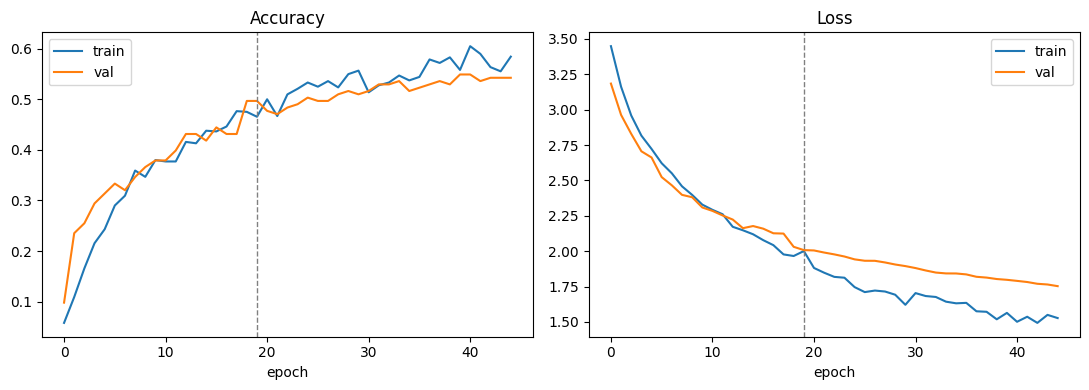

saved training_curves.png


In [ ]:
def plot_history(h1, h2, out="training_curves.png"):
    acc  = h1.history["accuracy"]     + h2.history["accuracy"]
    val  = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"]         + h2.history["loss"]
    vlos = h1.history["val_loss"]     + h2.history["val_loss"]
    cut  = len(h1.history["accuracy"]) - 1
    plt.figure(figsize=(11, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label="train"); plt.plot(val, label="val")
    plt.axvline(cut, ls="--", c="gray", lw=1)
    plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(loss, label="train"); plt.plot(vlos, label="val")
    plt.axvline(cut, ls="--", c="gray", lw=1)
    plt.title("Loss"); plt.xlabel("epoch"); plt.legend()
    plt.tight_layout(); plt.savefig(out, dpi=120); plt.show()
    print("saved", out)

plot_history(history1, history2)


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTEST accuracy: {test_acc*100:.2f}%   |   TEST loss: {test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4843 - loss: 2.0077

TEST accuracy: 48.43%   |   TEST loss: 2.0077


In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 785ms/step


In [ ]:
print("\nPer-class report:\n")
report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print(report)
with open("classification_report.txt", "w") as f:
    f.write(report)


Per-class report:

                          precision    recall  f1-score   support

    Acridotheres_tristis      0.500     0.500     0.500         6
           Alcedo_atthis      0.500     0.400     0.444         5
  Amaurornis_phoenicurus      0.714     0.833     0.769         6
          Ardeola_grayii      0.500     0.333     0.400         3
           Argya_striata      0.000     0.000     0.000         6
      Centropus_sinensis      0.556     0.833     0.667         6
      Cinnyris_asiaticus      0.400     0.667     0.500         6
           Columba_livia      0.600     0.500     0.545         6
   Coracias_benghalensis      0.500     0.167     0.250         6
   Dendrocitta_vagabunda      0.250     0.333     0.286         6
    Dicrurus_macrocercus      0.278     0.833     0.417         6
   Eudynamys_scolopaceus      0.200     0.167     0.182         6
      Halcyon_smyrnensis      0.200     0.333     0.250         6
       Merops_orientalis      0.000     0.000     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


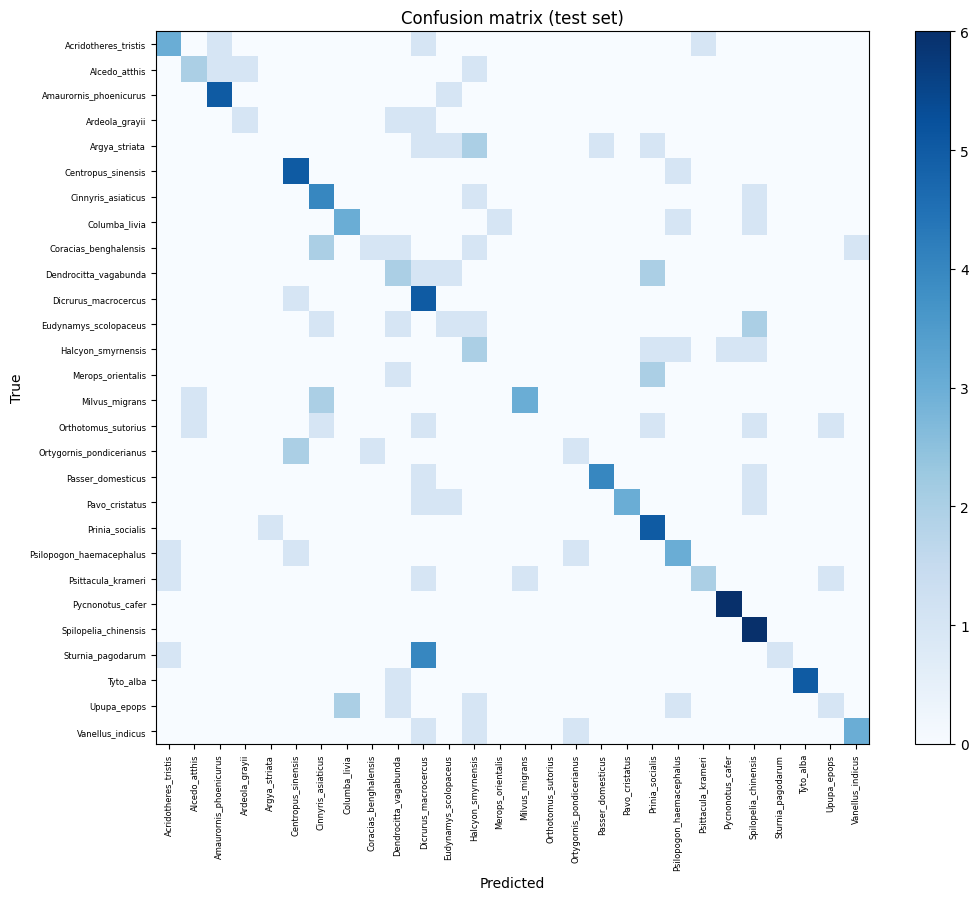

saved confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(11, 9))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix (test set)"); plt.colorbar()
ticks = np.arange(NUM_CLASSES)
plt.xticks(ticks, class_names, rotation=90, fontsize=6)
plt.yticks(ticks, class_names, fontsize=6)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=140); plt.show()
print("saved confusion_matrix.png")

In [12]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
SRC_DIR    = "/content/spectograms"
IMG_SIZE   = (224, 224)
MIN_IMAGES = 40

N_SPLITS   = 5

In [ ]:
all_classes = sorted(d for d in os.listdir(SRC_DIR)
                     if os.path.isdir(os.path.join(SRC_DIR, d)))
counts = {
    c: len([f for f in os.listdir(os.path.join(SRC_DIR, c))
            if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    for c in all_classes
}
kept    = [c for c in all_classes if counts[c] >= MIN_IMAGES]
dropped = [c for c in all_classes if counts[c] <  MIN_IMAGES]
print(f"Keeping {len(kept)}/{len(all_classes)} classes (>= {MIN_IMAGES} imgs):")
for c in kept:
    print(f"  {c}: {counts[c]}")
if dropped:
    print("Dropped (too few images):", dropped)
assert len(kept) >= 2, "Need at least 2 classes — lower MIN_IMAGES."

Keeping 24/28 classes (>= 40 imgs):
  Acridotheres_tristis: 40
  Amaurornis_phoenicurus: 40
  Argya_striata: 40
  Centropus_sinensis: 40
  Cinnyris_asiaticus: 40
  Columba_livia: 40
  Coracias_benghalensis: 40
  Dendrocitta_vagabunda: 40
  Dicrurus_macrocercus: 40
  Eudynamys_scolopaceus: 40
  Halcyon_smyrnensis: 40
  Milvus_migrans: 40
  Orthotomus_sutorius: 40
  Passer_domesticus: 40
  Pavo_cristatus: 40
  Prinia_socialis: 40
  Psilopogon_haemacephalus: 40
  Psittacula_krameri: 40
  Pycnonotus_cafer: 40
  Spilopelia_chinensis: 40
  Sturnia_pagodarum: 40
  Tyto_alba: 40
  Upupa_epops: 40
  Vanellus_indicus: 40
Dropped (too few images): ['Alcedo_atthis', 'Ardeola_grayii', 'Merops_orientalis', 'Ortygornis_pondicerianus']


In [ ]:
X_imgs, y = [], []
for idx, c in enumerate(kept):
    for f in os.listdir(os.path.join(SRC_DIR, c)):
        if not f.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        img = load_img(os.path.join(SRC_DIR, c, f), target_size=IMG_SIZE)
        X_imgs.append(img_to_array(img))
        y.append(idx)
X_imgs = np.array(X_imgs, dtype="float32")
y = np.array(y)
print("\nImages:", X_imgs.shape, " Labels:", y.shape)


Images: (960, 224, 224, 3)  Labels: (960,)


In [ ]:
extractor = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet",
    input_shape=(*IMG_SIZE, 3), pooling="avg",   # -> (N, 1280)
)
extractor.trainable = False
X_proc   = keras.applications.efficientnet.preprocess_input(X_imgs.copy())
features = extractor.predict(X_proc, batch_size=32, verbose=1)
print("Feature matrix:", features.shape)

30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step
Feature matrix: (960, 1280)


In [13]:
def evaluate(clf, name):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    accs = []
    for tr, te in skf.split(features, y):
        pipe = make_pipeline(StandardScaler(), clf)
        pipe.fit(features[tr], y[tr])
        accs.append(accuracy_score(y[te], pipe.predict(features[te])))
    accs = np.array(accs)
    print(f"{name:22s} {accs.mean()*100:5.2f}% +/- {accs.std()*100:4.2f}%  "
          f"folds={[round(a*100, 1) for a in accs]}")
    return accs.mean()

print("\n%d-fold CV accuracy:" % N_SPLITS)
results = {
    "logreg":     (LogisticRegression(max_iter=2000, C=1.0), "LogisticRegression"),
    "svm_rbf":    (SVC(kernel="rbf", C=10, gamma="scale"),    "SVM (RBF)"),
    "svm_linear": (SVC(kernel="linear", C=1.0),               "SVM (linear)"),
}
scores = {k: evaluate(clf, name) for k, (clf, name) in results.items()}
best_key = max(scores, key=scores.get)
best_clf = results[best_key][0]
print(f"\nBest: {results[best_key][1]} ({scores[best_key]*100:.2f}%)  ")


Overall CV accuracy: 80.00%

                          precision    recall  f1-score   support

    Acridotheres_tristis      0.795     0.775     0.785        40
  Amaurornis_phoenicurus      0.903     0.700     0.789        40
           Argya_striata      0.767     0.825     0.795        40
      Centropus_sinensis      0.821     0.800     0.810        40
      Cinnyris_asiaticus      0.875     0.875     0.875        40
           Columba_livia      0.919     0.850     0.883        40
   Coracias_benghalensis      0.811     0.750     0.779        40
   Dendrocitta_vagabunda      0.604     0.725     0.659        40
    Dicrurus_macrocercus      0.842     0.800     0.821        40
   Eudynamys_scolopaceus      0.656     0.525     0.583        40
      Halcyon_smyrnensis      0.683     0.700     0.691        40
          Milvus_migrans      0.725     0.725     0.725        40
     Orthotomus_sutorius      0.588     0.750     0.659        40
       Passer_domesticus      0.881     0.925

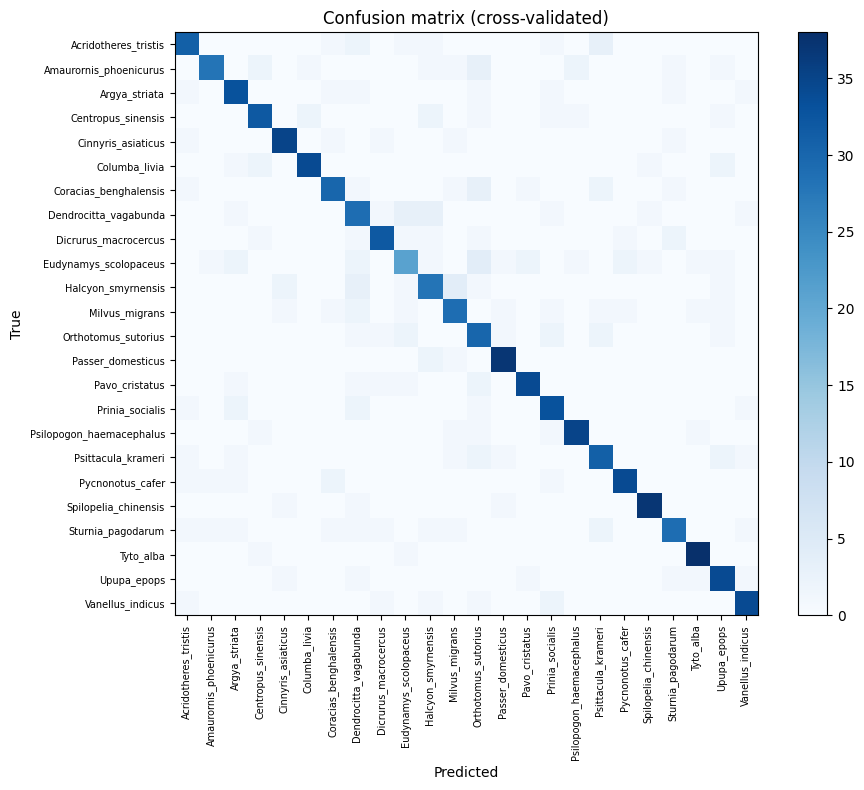

saved confusion_matrix.png


In [ ]:
pipe = make_pipeline(StandardScaler(), best_clf)
skf  = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
y_pred = cross_val_predict(pipe, features, y, cv=skf)
print(f"\nOverall CV accuracy: {accuracy_score(y, y_pred)*100:.2f}%\n")

report = classification_report(y, y_pred, target_names=kept, digits=3)
print(report)
with open("classification_report.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
t = np.arange(len(kept))
plt.xticks(t, kept, rotation=90, fontsize=7)
plt.yticks(t, kept, fontsize=7)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix (cross-validated)")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=140); plt.show()
print("saved confusion_matrix.png")

In [ ]:
final_clf = best_clf
if isinstance(final_clf, SVC):
    final_clf = SVC(kernel=final_clf.kernel,
                    C=final_clf.C,
                    gamma=getattr(final_clf, "gamma", "scale"),
                    probability=True)
final = make_pipeline(StandardScaler(), final_clf)
final.fit(features, y)

joblib.dump(final, "bird_clf.joblib")
extractor.save("feature_extractor.keras")
with open("class_names.json", "w") as f:
    json.dump(kept, f, indent=2)
print("saved bird_clf.joblib, feature_extractor.keras, class_names.json")

saved bird_clf.joblib, feature_extractor.keras, class_names.json


In [ ]:
def predict_species(img_path, top_k=3):
    img = load_img(img_path, target_size=IMG_SIZE)
    x = keras.applications.efficientnet.preprocess_input(
        np.expand_dims(img_to_array(img), 0))
    feat = extractor.predict(x, verbose=0)
    probs = final.predict_proba(feat)[0]
    top = probs.argsort()[-top_k:][::-1]
    return [(kept[i], round(float(probs[i]) * 100, 2)) for i in top]

In [ ]:
import sklearn, tensorflow, librosa
print(sklearn.__version__, tensorflow.__version__, librosa.__version__)

1.6.1 2.20.0 0.11.0


In [2]:
!pip install gradio

In [15]:
import io
import json
import joblib
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import librosa
import librosa.display
from PIL import Image

import gradio as gr
from tensorflow import keras
from tensorflow.keras.preprocessing.image import img_to_array

IMG_SIZE      = (224, 224)
N_MELS        = 128
CHUNK_SECONDS = 10
MAX_CHUNKS    = 8


clf = joblib.load("bird_clf.joblib")
with open("class_names.json") as f:
    CLASS_NAMES = json.load(f)

extractor = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet",
    input_shape=(*IMG_SIZE, 3), pooling="avg",
)
extractor.trainable = False


def chunk_to_image(chunk, sr):
    """Render one 10s chunk to the SAME magma mel-spectrogram PNG used in
    training, returned as a 224x224x3 array."""
    S = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)

    fig = plt.figure(figsize=(3, 3))
    librosa.display.specshow(S_dB, sr=sr, cmap="magma")
    plt.axis("off")
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    buf.seek(0)
    img = Image.open(buf).convert("RGB").resize(IMG_SIZE)
    return img_to_array(img)


def classify_audio(audio_path):
    if audio_path is None:
        return {}, None

    y, sr = librosa.load(audio_path, sr=None, mono=True)
    chunk_size = CHUNK_SECONDS * sr

    chunks = []
    for i in range(0, max(len(y), chunk_size), chunk_size):
        c = y[i:i + chunk_size]
        if len(c) < chunk_size:
            c = np.pad(c, (0, chunk_size - len(c)))
        chunks.append(c)
        if len(chunks) >= MAX_CHUNKS:
            break

    imgs  = np.stack([chunk_to_image(c, sr) for c in chunks])
    x     = keras.applications.efficientnet.preprocess_input(imgs)
    feats = extractor.predict(x, verbose=0)
    probs = clf.predict_proba(feats).mean(axis=0)

    result  = {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}
    preview = Image.fromarray(imgs[0].astype("uint8"))
    return result, preview


DESCRIPTION = (
    "Upload or record a **bird call** and get the top-3 most likely species "
    "(24 Indian birds). The audio is split into 10-second segments, each turned into a "
    "mel-spectrogram and classified with a frozen EfficientNetB0 + logistic-regression "
    "model (~80%, 5-fold CV); the segment predictions are averaged. "
    "Works best on reasonably clean recordings — the model was trained on Xeno-canto "
    "quality-A audio."
)

demo = gr.Interface(
    fn=classify_audio,
    inputs=gr.Audio(sources=["upload", "microphone"], type="filepath",
                    label="Bird call (upload a file or record)"),
    outputs=[
        gr.Label(num_top_classes=3, label="Top 3 predicted species"),
        gr.Image(label="Mel-spectrogram (first 10s)"),
    ],
    title="Bird Call Classifier — audio in, species out",
    description=DESCRIPTION,
    flagging_mode="never",
)

if __name__ == "__main__":
    demo.launch()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://771fe75e1bac45e796.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
